# **Lab 5**

---
Write a CNN model for handwritten digit classification using the MNIST dataset.

CNN architecture: Convolution -> ReLU -> Pool -> Flatten -> Dense
---
**Deep learning& GenAI 2026-27 V-B**  
**Name:** Ojasv Singh  
**University Roll No.:** 202401100500120  
**CSIT - B**

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier


In [2]:
mnist, labels = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
mnist = mnist.astype("float32") / 255.0
labels = labels.astype("int64")

x_train = mnist[:60000].reshape(-1, 28, 28)
y_train = labels[:60000]
x_test = mnist[60000:].reshape(-1, 28, 28)
y_test = labels[60000:]

print("Training images shape : ", x_train.shape)
print("Training labels shape : ", y_train.shape)
print("Test images shape : ", x_test.shape)
print("Test labels shape : ", y_test.shape)


Training images shape :  (60000, 28, 28)
Training labels shape :  (60000,)
Test images shape :  (10000, 28, 28)
Test labels shape :  (10000,)


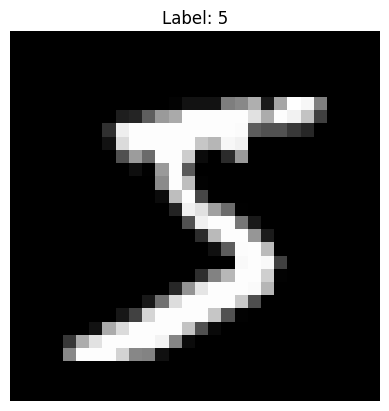

In [3]:
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [4]:
print("Normalized pixel range : ", x_train.min(), "to", x_train.max())
print("CNN input shape : ", x_train.shape[1:])


Normalized pixel range :  0.0 to 1.0
CNN input shape :  (28, 28)


In [5]:
# Convolution -> ReLU -> Pool -> Flatten
convolution_filters = np.array([
    [[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]],
    [[-1, -1, -1], [0, 0, 0], [1, 1, 1]],
    [[1, 1, 1], [1, -8, 1], [1, 1, 1]],
    [[1, 0, -1], [0, 0, 0], [-1, 0, 1]]
], dtype="float32")


def cnn_features(images):
    pooled_outputs = []
    for image in images:
        feature_maps = []
        for kernel in convolution_filters:
            convolved = convolve2d(image, kernel, mode="valid")
            relu_output = np.maximum(convolved, 0)
            pooled = relu_output.reshape(13, 2, 13, 2).max(axis=(1, 3))
            feature_maps.append(pooled)
        pooled_outputs.append(np.stack(feature_maps))
    return np.asarray(pooled_outputs, dtype="float32")


print("Convolution filters shape : ", convolution_filters.shape)
print("After pooling shape : (4, 13, 13)")


Convolution filters shape :  (4, 3, 3)
After pooling shape : (4, 13, 13)


In [6]:
train_count = 12000
test_count = 2000

train_features = cnn_features(x_train[:train_count])
test_features = cnn_features(x_test[:test_count])

# Flatten -> Dense
train_features = train_features.reshape(train_count, -1)
test_features = test_features.reshape(test_count, -1)

dense_layer = SGDClassifier(loss="log_loss", max_iter=15, random_state=42)
dense_layer.fit(train_features, y_train[:train_count])

print("Flattened feature shape : ", train_features.shape)
print("Dense layer output size : 10")


Flattened feature shape :  (12000, 676)
Dense layer output size : 10


d:\Programs\Python\Python10\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [7]:
predicted_test_labels = dense_layer.predict(test_features)
test_accuracy = np.mean(predicted_test_labels == y_test[:test_count])
print("Test accuracy : ", test_accuracy)


Test accuracy :  0.9395


Actual labels :  [7 2 1 0 4]
Predicted labels:  [7 2 1 0 4]


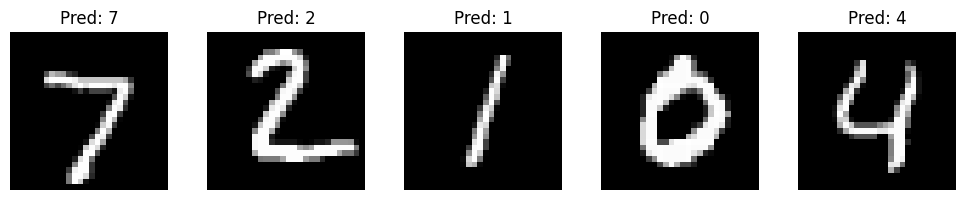

In [8]:
predicted_labels = dense_layer.predict(test_features[:5])

print("Actual labels : ", y_test[:5])
print("Predicted labels: ", predicted_labels)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for index, axis in enumerate(axes):
    axis.imshow(x_test[index], cmap="gray")
    axis.set_title(f"Pred: {predicted_labels[index]}")
    axis.axis("off")
plt.tight_layout()
plt.show()
